<a href="https://colab.research.google.com/github/cxanvy/DAU2026_BigData/blob/main/%5B%EA%B3%BC%EC%A0%9C4%5D_%EC%8A%A4%ED%8A%B8%EB%A6%AC%EB%B0%8D_%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98_%EB%B9%84%EA%B5%90_%EC%8B%A4%ED%97%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터셋이 이미 존재합니다.

데이터 읽기 및 리스트 캐싱 진행 중...
데이터셋의 총 라인 수: 1000209

--- Reservoir Sampling 파라미터(k)별 비교 실험 실행 중 ---
[테스트 진행] 샘플 크기 k = 100 처리 중... 완료!
[테스트 진행] 샘플 크기 k = 1000 처리 중... 완료!
[테스트 진행] 샘플 크기 k = 10000 처리 중... 완료!

Reservoir Sampling 파라미터 비교 결과 데이터프레임:
 샘플 크기 (k)  소요 시간 (초)  최대 메모리 (MB)  샘플 내 고유 사용자수  기준 데이터 고유 사용자수
       100   2.599664     0.002114            98              96
      1000   3.336184     0.009915           844             848
     10000   4.255517     0.082692          3717            3665


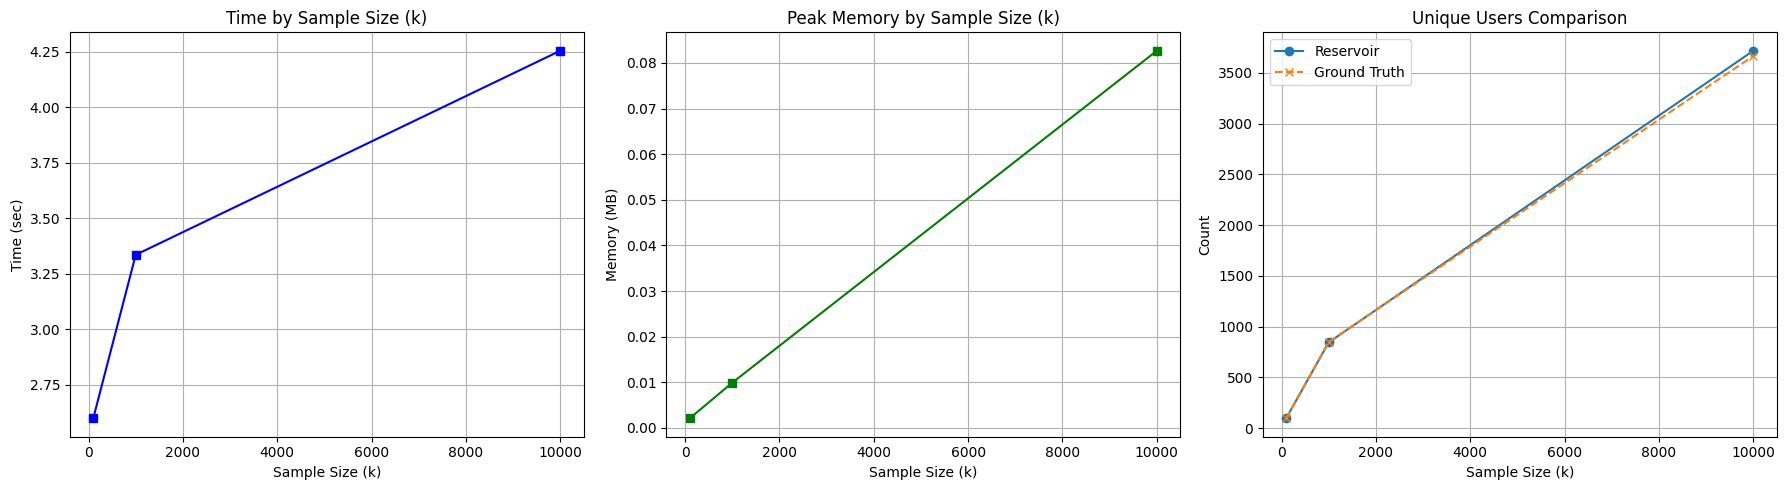


블룸 필터의 원본 기준 데이터(Ground Truth) 계산 중...

블룸 필터 파라미터별 비교 실험 실행 중...
블룸 필터 초기화: 수용량=6040, 오차율=0.1 -> 비트수=28946, 해시수=3
블룸 필터 초기화: 수용량=6040, 오차율=0.01 -> 비트수=57893, 해시수=6
블룸 필터 초기화: 수용량=6040, 오차율=0.001 -> 비트수=86840, 해시수=9

블룸 필터 파라미터 비교 결과:
 설정 오차율 (Error Rate)  비트 수 (m)  해시 개수 (k)  실제 위양성율 (Actual FPR)  메모리 사용량 (MB)  처리 시간 (초)
               0.100     28946          3              0.098098      0.224344   0.005790
               0.010     57893          6              0.008008      0.448643   0.009169
               0.001     86840          9              0.001001      0.672942   0.013321


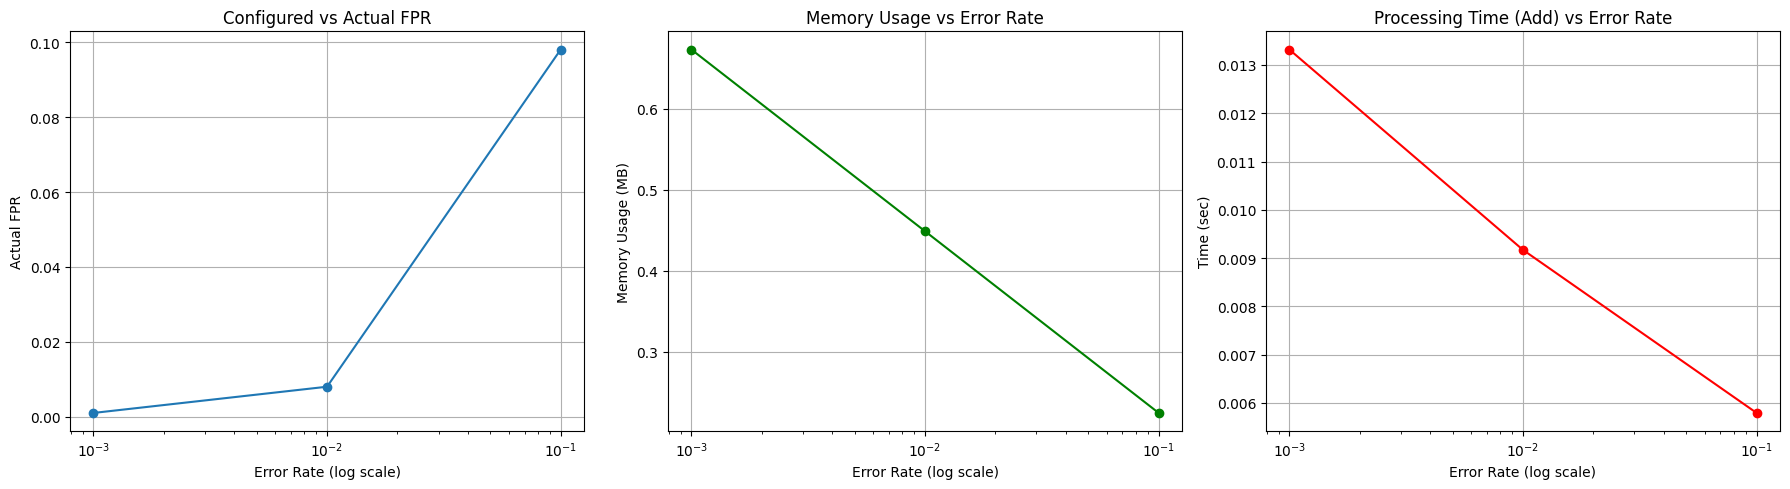

In [4]:
import os
import requests
import zipfile
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import random
import sys
import time
import pandas as pd
import tracemalloc
import mmh3 # 빠른 해싱을 위해 murmurhash3 라이브러리 사용 (pip install mmh3)
import math
import matplotlib.pyplot as plt

# =====================================================================
# [코랩 전용 폰트 설정] 리눅스 내장 폰트를 활용해 한글 깨짐 방지
# =====================================================================
plt.rcParams['font.family'] = 'DejaVu Sans' # 코랩 기본 영문 폰트 지정 (한글은 시스템 내장 폰트로 자동 대체)
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

dataset_url = "https://files.grouplens.org/datasets/movielens/ml-1m.zip"
dataset_path = "ml-1m.zip"
extract_path = "ml-1m"

if not os.path.exists(extract_path):
    print(f"데이터셋 다운로드 중: {dataset_url}...")
    session = requests.Session()
    retry_strategy = Retry(
        total=5,
        backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["HEAD", "GET", "OPTIONS"]
    )
    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    try:
        response = session.get(dataset_url, timeout=30)
        response.raise_for_status()
        with open(dataset_path, "wb") as f:
            f.write(response.content)
        print(f"압축 해제 중: {dataset_path}...")
        with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("데이터셋 준비가 완료되었습니다!")
    except requests.exceptions.RequestException as e:
        print(f"데이터셋 다운로드 또는 압축 해제 실패: {e}")
        if os.path.exists(dataset_path):
            os.remove(dataset_path)
else:
    print("데이터셋이 이미 존재합니다.")

# 데이터 파일 경로 설정
ratings_file = os.path.join(extract_path, extract_path, "ratings.dat")

class ReservoirSampling:
    def __init__(self, k):
        if k <= 0:
            raise ValueError("샘플 크기 'k'는 양의 정수여야 합니다.")
        self.k = k
        self.reservoir = []
        self.count = 0

    def add_item(self, item):
        self.count += 1
        if len(self.reservoir) < self.k:
            self.reservoir.append(item)
        else:
            rand_idx = random.randrange(self.count)
            if rand_idx < self.k:
                self.reservoir[rand_idx] = item

    def get_sample(self):
        return self.reservoir

def get_user_id(line_data):
    try:
        return int(line_data.split('::')[0])
    except (ValueError, IndexError):
        return None

print("\n데이터 읽기 및 리스트 캐싱 진행 중...")
all_lines = []
with open(ratings_file, 'r') as f:
    for line in f:
        all_lines.append(line.strip())
print(f"데이터셋의 총 라인 수: {len(all_lines)}")

# --- Reservoir Sampling 파라미터(k)별 비교 실험 실행 중 ---
print("\n--- Reservoir Sampling 파라미터(k)별 비교 실험 실행 중 ---")
k_values_to_test = [100, 1000, 10000]
rs_results = []

for k_val in k_values_to_test:
    print(f"[테스트 진행] 샘플 크기 k = {k_val} 처리 중...", end="", flush=True)

    tracemalloc.start()
    start_time_rs = time.time()

    reservoir_sampler = ReservoirSampling(k_val)
    for line in all_lines:
        reservoir_sampler.add_item(line)

    end_time_rs = time.time()
    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    sampled_data = reservoir_sampler.get_sample()
    processing_time = end_time_rs - start_time_rs

    rs_user_ids = [get_user_id(item) for item in sampled_data if get_user_id(item) is not None]
    rs_unique_users = len(set(rs_user_ids))

    random.seed(42)
    gt_sample = random.sample(all_lines, k_val)
    gt_user_ids = [get_user_id(item) for item in gt_sample if get_user_id(item) is not None]
    gt_unique_users = len(set(gt_user_ids))

    rs_results.append({
        '샘플 크기 (k)': k_val,
        '소요 시간 (초)': processing_time,
        '최대 메모리 (MB)': peak_mem / (1024 * 1024),
        '샘플 내 고유 사용자수': rs_unique_users,
        '기준 데이터 고유 사용자수': gt_unique_users
    })
    print(" 완료!")

rs_results_df = pd.DataFrame(rs_results)
print("\nReservoir Sampling 파라미터 비교 결과 데이터프레임:")
print(rs_results_df.to_string(index=False))

# Reservoir Sampling 실험 결과 시각화
fig_rs, axes_rs = plt.subplots(1, 3, figsize=(18, 5))

axes_rs[0].plot(rs_results_df['샘플 크기 (k)'], rs_results_df['소요 시간 (초)'], marker='s', color='blue')
axes_rs[0].set_title('Time by Sample Size (k)')
axes_rs[0].set_xlabel('Sample Size (k)')
axes_rs[0].set_ylabel('Time (sec)')
axes_rs[0].grid(True)

axes_rs[1].plot(rs_results_df['샘플 크기 (k)'], rs_results_df['최대 메모리 (MB)'], marker='s', color='green')
axes_rs[1].set_title('Peak Memory by Sample Size (k)')
axes_rs[1].set_xlabel('Sample Size (k)')
axes_rs[1].set_ylabel('Memory (MB)')
axes_rs[1].grid(True)

axes_rs[2].plot(rs_results_df['샘플 크기 (k)'], rs_results_df['샘플 내 고유 사용자수'], marker='o', label='Reservoir')
axes_rs[2].plot(rs_results_df['샘플 크기 (k)'], rs_results_df['기준 데이터 고유 사용자수'], marker='x', linestyle='--', label='Ground Truth')
axes_rs[2].set_title('Unique Users Comparison')
axes_rs[2].set_xlabel('Sample Size (k)')
axes_rs[2].set_ylabel('Count')
axes_rs[2].legend()
axes_rs[2].grid(True)

plt.tight_layout()
plt.show()


class BloomFilter:
    def __init__(self, capacity, error_rate):
        self.capacity = capacity
        self.error_rate = error_rate

        self.num_bits = int(-(capacity * math.log(error_rate)) / (math.log(2) ** 2))
        if self.num_bits <= 0:
            self.num_bits = 1

        self.num_hashes = int((self.num_bits / capacity) * math.log(2))
        if self.num_hashes <= 0:
            self.num_hashes = 1

        self.bit_array = [0] * self.num_bits
        self.count = 0

        print(f"블룸 필터 초기화: 수용량={capacity}, 오차율={error_rate} -> 비트수={self.num_bits}, 해시수={self.num_hashes}")

    def _get_hashes(self, item):
        hashes = []
        for i in range(self.num_hashes):
            h = mmh3.hash(item, i) % self.num_bits
            hashes.append(h)
        return hashes

    def add(self, item):
        for h in self._get_hashes(item):
            self.bit_array[h] = 1
        self.count += 1

    def contains(self, item):
        for h in self._get_hashes(item):
            if self.bit_array[h] == 0:
                return False
        return True

    def get_memory_usage(self):
        return sys.getsizeof(self.bit_array) + (self.num_bits // 8)


print("\n블룸 필터의 원본 기준 데이터(Ground Truth) 계산 중...")
ground_truth_set = set()
actual_unique_user_ids = set()
for line in all_lines:
    parts = line.split('::')
    if len(parts) == 4:
        user_id = parts[0]
        ground_truth_set.add(user_id)
        actual_unique_user_ids.add(user_id)

max_user_id = max([int(uid) for uid in ground_truth_set])
non_existent_user_ids = [str(max_user_id + i) for i in range(1, 1000)]

print("\n블룸 필터 파라미터별 비교 실험 실행 중...")
expected_elements = 6040
error_rates_to_test = [0.1, 0.01, 0.001]
bf_results = []

for err_rate in error_rates_to_test:
    bf_test = BloomFilter(expected_elements, err_rate)

    start_time_test = time.time()
    for user_id in actual_unique_user_ids:
        bf_test.add(user_id)
    end_time_test = time.time()

    false_positives_test = 0
    for user_id in non_existent_user_ids:
        if bf_test.contains(user_id):
            false_positives_test += 1
    actual_fpr = false_positives_test / len(non_existent_user_ids) if len(non_existent_user_ids) > 0 else 0

    mem_usage_mb = bf_test.get_memory_usage() / (1024 * 1024)
    processing_time_sec = end_time_test - start_time_test

    bf_results.append({
        '설정 오차율 (Error Rate)': err_rate,
        '비트 수 (m)': bf_test.num_bits,
        '해시 개수 (k)': bf_test.num_hashes,
        '실제 위양성율 (Actual FPR)': actual_fpr,
        '메모리 사용량 (MB)': mem_usage_mb,
        '처리 시간 (초)': processing_time_sec
    })

bf_results_df = pd.DataFrame(bf_results)
print("\n블룸 필터 파라미터 비교 결과:")
print(bf_results_df.to_string(index=False))

# 블룸 필터 실험 결과 시각화
fig_bf, axes_bf = plt.subplots(1, 3, figsize=(18, 5))

axes_bf[0].plot(bf_results_df['설정 오차율 (Error Rate)'], bf_results_df['실제 위양성율 (Actual FPR)'], marker='o')
axes_bf[0].set_xscale('log')
axes_bf[0].set_title('Configured vs Actual FPR')
axes_bf[0].set_xlabel('Error Rate (log scale)')
axes_bf[0].set_ylabel('Actual FPR')
axes_bf[0].grid(True)

axes_bf[1].plot(bf_results_df['설정 오차율 (Error Rate)'], bf_results_df['메모리 사용량 (MB)'], marker='o', color='green')
axes_bf[1].set_xscale('log')
axes_bf[1].set_title('Memory Usage vs Error Rate')
axes_bf[1].set_xlabel('Error Rate (log scale)')
axes_bf[1].set_ylabel('Memory Usage (MB)')
axes_bf[1].grid(True)

axes_bf[2].plot(bf_results_df['설정 오차율 (Error Rate)'], bf_results_df['처리 시간 (초)'], marker='o', color='red')
axes_bf[2].set_xscale('log')
axes_bf[2].set_title('Processing Time (Add) vs Error Rate')
axes_bf[2].set_xlabel('Error Rate (log scale)')
axes_bf[2].set_ylabel('Time (sec)')
axes_bf[2].grid(True)

plt.tight_layout()
plt.show()